# Data Project 1

In [31]:
# We start by importing the neccesary packages for importing and treating data from statistikbanken.
import requests
import numpy as np
import re
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO

## 1 Aggregate inflation in Denmark
### 1.1 Basics

In [32]:
# Defining the api from Statistikbanken as base url
BASE = "https://api.statbank.dk/v1"

In [33]:
# Creating a class to interact with the DST API
class DstApi:
    def __init__(self, table_id: str):
        self.table_id = table_id.upper()

    def tableinfo(self, language: str = "da") -> dict:
        """Fetch metadata for the table."""
        payload = {"table": self.table_id, "format": "JSON", "lang": language}
        r = requests.post(f"{BASE}/tableinfo", json=payload)
        r.raise_for_status()
        return r.json()

    def get_csv(self, params: dict) -> pd.DataFrame:
        """
        Fetch data as CSV and return a pandas DataFrame.
        """
        r = requests.post(f"{BASE}/data", json=params)
        r.raise_for_status()
        return pd.read_csv(StringIO(r.text), sep=";", decimal=",") 

def pick_cpi_value_id(meta: dict) -> tuple[str, str]:
    """
    We find the variable and value-id that correspond to the 'Forbrugerprisindeks' aggregate in PRIS113.
    Returns (variable_code, value_id). Raises if not found.
    """
    for v in meta.get("variables", []):
        texts = [val.get("text", "").lower() for val in v.get("values", [])]
        ids   = [val.get("id") for val in v.get("values", [])]
        for val_text, val_id in zip(texts, ids):
            if "forbrugerprisindeks" in val_text:
                return v["id"], val_id
    raise RuntimeError("Could not find 'Forbrugerprisindeks' in PRIS113 metadata. Inspect tableinfo() output.")

def parse_time_column(series: pd.Series) -> pd.Series:
    """
    Convert DST monthly labels like '2020M01' into pandas Timestamps.
    """
    def _parse(s: str):
        s = str(s).strip().replace("M", "-")  # '2020M01' -> '2020-01'
        try:
            return pd.to_datetime(s, format="%Y-%m")
        except Exception:
            return pd.to_datetime(s, errors="coerce")
    return series.apply(_parse)


In [34]:
# We setup the api for the table PRIS113. And defining the parameters for the data requested in the question.
api = DstApi("PRIS113")
meta = api.tableinfo(language="da")

# Choose CPI aggregate
var_code, cpi_id = pick_cpi_value_id(meta)

# Build request params: CPI aggregate + all months
params = {
    "table": "PRIS113",
    "format": "CSV",
    "lang": "da",
    "variables": [
        {"code": var_code, "values": [cpi_id]},
        # Time may be named 'TID' in StatBank tables
        {"code": meta["time"]["id"] if "time" in meta else "TID", "values": ["*"]},
    ],
}

raw = api.get_csv(params)


In [35]:
# We try to infer the time and value columns from the dataframe.
time_candidates  = [c for c in raw.columns if c.lower() in ("tid", "time", "måned", "maaned", "month")]
value_candidates = [c for c in raw.columns if c.lower() in ("indhold", "value", "values", "data")]
if not time_candidates or not value_candidates:
    raise RuntimeError(f"Could not infer time/value columns from: {list(raw.columns)}")

tcol = time_candidates[0]
vcol = value_candidates[0]

df = raw.copy()
df["date"] = parse_time_column(df[tcol])
df["cpi_2015eq100"] = pd.to_numeric(df[vcol], errors="coerce")


In [36]:
# We set the base year to 2020 average  
base_2020 = df.loc[df["date"].dt.year == 2020, "cpi_2015eq100"].mean()
if pd.isna(base_2020):
    raise RuntimeError("No 2020 observations found to compute the 2020-average base.")
df["cpi_2020avg_100"] = df["cpi_2015eq100"] / base_2020 * 100.0


In [37]:
# We calculate the inflation rates
df["mom_inflation_pct"] = df["cpi_2015eq100"].pct_change(1) * 100.0      # month-over-month
df["yoy_inflation_pct"] = df["cpi_2015eq100"].pct_change(12) * 100.0     # year-over-year


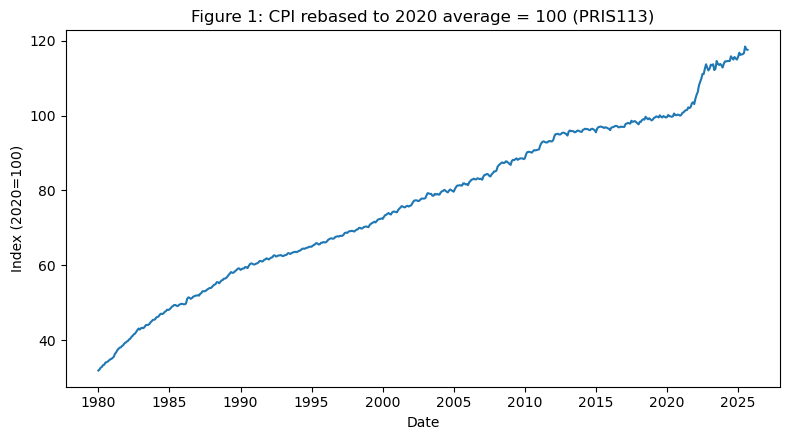

In [38]:
# Plotting the figures. First figure 1: CPI rebased to 2020 average = 100
plt.figure(figsize=(8, 4.5))
plt.plot(df["date"], df["cpi_2020avg_100"])
plt.title("Figure 1: CPI rebased to 2020 average = 100 (PRIS113)")
plt.xlabel("Date"); plt.ylabel("Index (2020=100)")
plt.tight_layout(); plt.show()


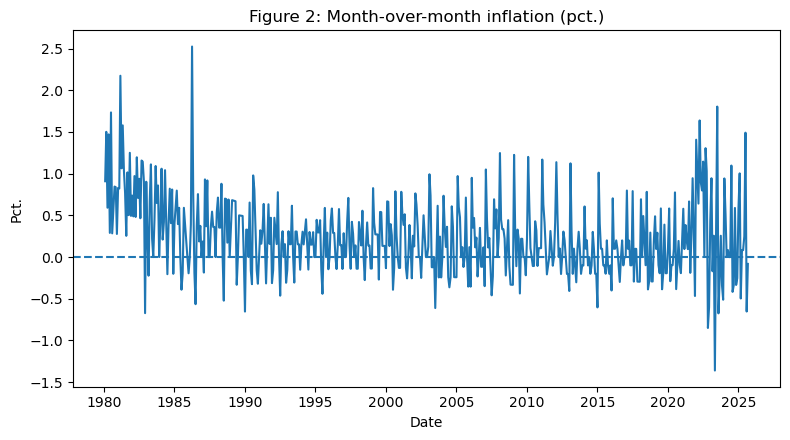

In [39]:
# Figure 2: Month-over-month inflation rates
plt.figure(figsize=(8, 4.5))
plt.plot(df["date"], df["mom_inflation_pct"])
plt.axhline(0, linestyle="--")
plt.title("Figure 2: Month-over-month inflation (pct.)")
plt.xlabel("Date"); plt.ylabel("Pct.")
plt.tight_layout(); plt.show()


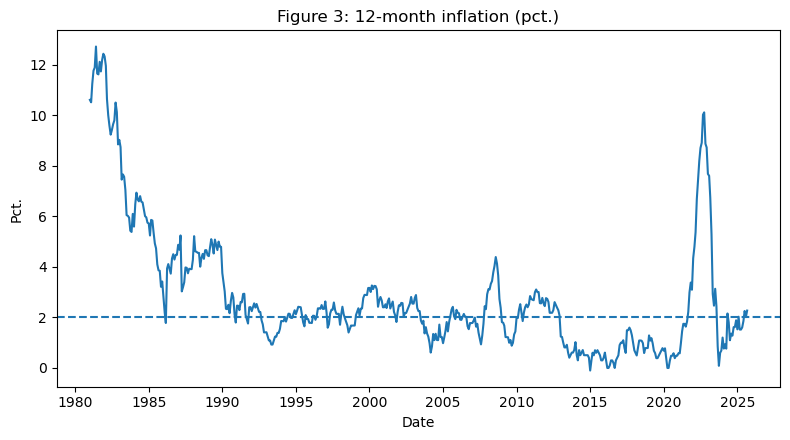

In [40]:
# Figure 3: 12-month inflation
plt.figure(figsize=(8, 4.5))
plt.plot(df["date"], df["yoy_inflation_pct"])
plt.axhline(2, linestyle="--")
plt.title("Figure 3: 12-month inflation (pct.)")
plt.xlabel("Date"); plt.ylabel("Pct.")
plt.tight_layout(); plt.show()

We find that the post pandemic inflation surge ended in approximately 2023, having prevoiusly topped in 2022. 

### 1.2 Instantaneous inflation

In [41]:
# Defining the api for the table PRIS113. And defining the parameters for the data requested in the question.
type_code, cpi_id = next(
    (v["id"], val["id"])
    for v in meta["variables"]
    for val in v["values"]
    if "forbrugerprisindeks" in (val.get("text","").lower())
)

params = {
    "table": "PRIS113", "format": "CSV", "lang": "da",
    "variables": [
        {"code": type_code, "values": [cpi_id]},
        {"code": meta["time"]["id"] if "time" in meta else "TID", "values": ["*"]},
    ],
}
raw = api.get_csv(params)

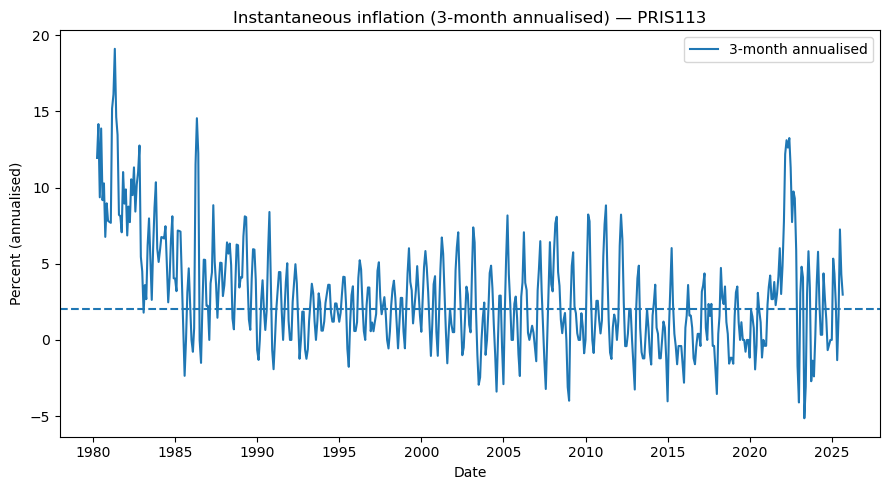

In [42]:
# 2) Tidy to a clean monthly CPI level (2015=100)
tcol = next(c for c in raw.columns if c.lower() in ("tid","time","måned","maaned","month"))
vcol = next(c for c in raw.columns if c.lower() in ("indhold","value","values","data"))

cpi = raw[[tcol, vcol]].rename(columns={tcol:"date", vcol:"cpi_2015eq100"})
cpi["date"] = parse_time_column(cpi["date"])
cpi["cpi_2015eq100"] = pd.to_numeric(cpi["cpi_2015eq100"], errors="coerce")
cpi = cpi.sort_values("date").reset_index(drop=True)

#Rebase to 2020 average = 100 
base_2020 = cpi.loc[cpi["date"].dt.year == 2020, "cpi_2015eq100"].mean()
cpi["cpi_2020avg_100"] = cpi["cpi_2015eq100"] / base_2020 * 100.0

def instantaneous_annualised(series, months):
    # Log-difference → annualized (times 12/months → pct)
    return 100 * (np.log(series / series.shift(months)) * (12 / months))

# 3) Instantaneous (annualised) inflation: 1m, 3m, 6m
cpi["inst_1m_pct"] = instantaneous_annualised(cpi["cpi_2015eq100"], 1)
cpi["inst_3m_pct"] = instantaneous_annualised(cpi["cpi_2015eq100"], 3)
cpi["inst_6m_pct"] = instantaneous_annualised(cpi["cpi_2015eq100"], 6)

# 4) One concise plot of instantaneous inflation (3-month annualised)
plt.figure(figsize=(9,5))
plt.plot(cpi["date"], cpi["inst_3m_pct"], label="3-month annualised")
plt.axhline(2, linestyle="--")
plt.title("Instantaneous inflation (3-month annualised) — PRIS113")
plt.xlabel("Date"); plt.ylabel("Percent (annualised)")
plt.legend()
plt.tight_layout(); plt.show()




### 1.3 Core inflation

In [43]:
# Reuses: DstApi, parse_time_column from Assignment 1.1

# Define constants for CPI aggregates
TARGET = ["000000", "151000", "141000"]
LABEL = {
    "000000": "CPI total (000000)",
    "151000": "Excl. energy (151000)",
    "141000": "Core: excl. energy & unprocessed food (141000)",
}


In [44]:

def yoy_12m(x: pd.Series) -> pd.Series:
    return (x / x.shift(12) - 1.0) * 100.0

def varegr_text_to_code(s):
    if pd.isna(s): return None
    s = str(s).strip()
    if s.isdigit() and len(s) == 6:  # already code
        return s
    m = re.match(r"^\s*(\d{2})\.(\d)\b", s)   # "14.1 ..." -> 141000
    if m: return f"{m.group(1)}{m.group(2)}000"
    m = re.match(r"^\s*(\d{3})\b", s)         # "151 ..."  -> 151000
    if m: return f"{m.group(1)}000"
    m = re.match(r"^\s*(\d{2})\b", s)         # "00 ..."   -> 000000
    if m: return f"{m.group(1)}0000"
    return None


In [45]:
# Getting the data from statistikbanken
api = DstApi("PRIS111")
meta = api.tableinfo(language="da")


In [46]:
# Robust time variable
time_var = meta.get("time")
if time_var is None:
    for v in meta.get("variables", []):
        vid = (v.get("id") or "").lower()
        vtxt = (v.get("text","") or "").lower()
        if vid in ("tid","time","t") or any(k in vtxt for k in ("tid","måned","month","periode")):
            time_var = v; break
time_code = time_var["id"] if time_var else "TID"

# Category variable: VAREGR
varegr_var = next((v for v in meta["variables"] if v["id"].upper()=="VAREGR"), None)
if varegr_var is None:
    raise RuntimeError("VAREGR not found in PRIS111 metadata.")
varegr_code = varegr_var["id"]

# ENHED + Season
enhed_var  = next((v for v in meta["variables"] if "ENHED" in v["id"].upper() or "unit" in (v.get("text","").lower())), None)
season_var = next((v for v in meta["variables"] if "sæson" in (v.get("text","").lower()) or "season" in (v.get("text","").lower())), None)


In [47]:
def pick_enhed_id(v):
    """Pick an index-level unit robustly (avoid pct/changes)."""
    bad = ("pct", "procent", "ændring", "aendring", "change", "%")
    candidates = []
    for val in v.get("values", []):
        txt = (val.get("text","") or "")
        txt_l = txt.lower()
        if "indeks" in txt_l and not any(b in txt_l for b in bad):
            # prefer ones that mention 2015 or '=100'
            score = 2*("2015" in txt) + 1*("=100" in txt or "100" in txt)
            candidates.append((score, val["id"], txt))
    if candidates:
        candidates.sort(reverse=True)  # highest score first
        chosen = candidates[0]
        if chosen[0] < 1:
            print(f"[warn] ENHED matched an index without explicit base (picked: {chosen[2]})")
        return chosen[1]
    # fallback: print available and pick first
    opts = [val.get("text","") for val in v.get("values",[])]
    print("[warn] Could not find clear 'Indeks (2015=100)'. Available ENHED values include:", opts[:8], "...")
    return v["values"][0]["id"]

def pick_season_id(v):
    for val in v.get("values", []):
        t = (val.get("text","") or "").lower()
        if "ikke sæson" in t or "not season" in t:
            return val["id"]
    return v["values"][0]["id"]


In [48]:

# Build request: VAREGR="*", ENHED=index-level, Sæson=ikke sæson (if available), time="*"
variables = []
for v in meta["variables"]:
    code = v["id"]
    if code == time_code:
        continue
    if code == varegr_code:
        variables.append({"code": code, "values": ["*"]})
    elif enhed_var is not None and code == enhed_var["id"]:
        variables.append({"code": code, "values": [pick_enhed_id(enhed_var)]})
    elif season_var is not None and code == season_var["id"]:
        variables.append({"code": code, "values": [pick_season_id(season_var)]})
    else:
        first = v["values"][0]["id"] if v.get("values") else "*"
        variables.append({"code": code, "values": [first]})
variables.append({"code": time_code, "values": ["*"]})

params = {"table": "PRIS111", "format": "CSV", "lang": "da", "variables": variables}
raw = api.get_csv(params)


[warn] ENHED matched an index without explicit base (picked: Indeks)


In [49]:
# ---- Tidy & numeric levels
time_col  = next(c for c in raw.columns if c.lower() in ("tid","time","måned","maaned","month"))
value_col = next(c for c in raw.columns if c.lower() in ("indhold","value","values","data"))

df = raw[[time_col, "VAREGR", value_col]].copy()
df["date"] = parse_time_column(df[time_col])


In [50]:
# Parse numeric robustly (Danish thousands/decimal)
if pd.api.types.is_numeric_dtype(df[value_col]):
    df["level"] = df[value_col].astype(float)
else:
    df["level"] = (
        df[value_col].astype(str)
        .str.replace(".", "", regex=False)   # thousands dot
        .str.replace(",", ".", regex=False)  # decimal comma -> dot
        .pipe(pd.to_numeric, errors="coerce")
    )

# Map VAREGR text -> 6-digit codes, keep targets
df["VAREGR_ID"] = df["VAREGR"].apply(varegr_text_to_code)
df = df[df["VAREGR_ID"].isin(TARGET)].copy()

# Basic sanity: drop non-positive levels
df.loc[df["level"] <= 0, "level"] = pd.NA

# Pivot to wide index levels and compute YoY
wide = df.pivot(index="date", columns="VAREGR_ID", values="level").sort_index()
yoy  = wide.apply(yoy_12m)


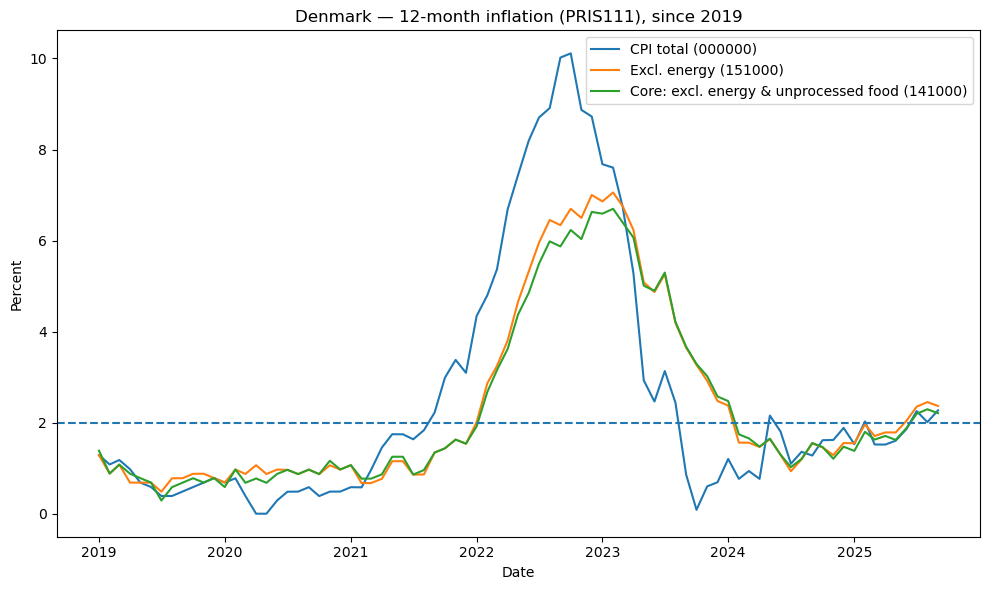

Latest 12m inflation — CPI total (000000): 2.27% | Excl. energy (151000): 2.37% | Core: excl. energy & unprocessed food (141000): 2.21%  (at 2025-09)


In [51]:

# Plot since 2019
yoy_2019 = yoy.loc[yoy.index >= pd.Timestamp("2019-01-01")]

# Plotting the 12-month inflation rates for the target aggregates
plt.figure(figsize=(10,6))
plotted = False
for vid in TARGET:
    if vid in yoy_2019.columns and yoy_2019[vid].notna().any():
        plt.plot(yoy_2019.index, yoy_2019[vid], label=LABEL[vid])
        plotted = True
plt.axhline(2, linestyle="--")
plt.title("Denmark — 12-month inflation (PRIS111), since 2019")
plt.xlabel("Date"); plt.ylabel("Percent")
if plotted: plt.legend()
plt.tight_layout(); plt.show()

if plotted and not yoy_2019.dropna(how="any").empty:
    last_idx = yoy_2019.dropna(how="any").index.max()
    outs = " | ".join(f"{LABEL[k]}: {yoy_2019.loc[last_idx,k]:.2f}%" for k in TARGET if k in yoy_2019.columns)
    print(f"Latest 12m inflation — {outs}  (at {last_idx:%Y-%m})")
else:
    print("No valid YoY rows — check the [warn] lines above to see which ENHED/Sæson was chosen.")



According to the chart we can derive that the rising inflation during the postpandemic period was caused by rising energy and unprocessed food prices. This is partly a consequence of the russian invasion in Ukraine and less influenced by the blockage of the Suez canal.

### 1.4 Disaggregated inflation in Denmark

Detailed CPI product categories (code + label):
01.1  01.1 Fødevarer
01.1.1  01.1.1 Brød og kornprodukter
01.1.1.1  01.1.1.1 Ris
01.1.1.2  01.1.1.2 Mel og gryn
01.1.1.3  01.1.1.3 Brød
01.1.1.4  01.1.1.4 Andet bagværk
01.1.1.5  01.1.1.5 Pizza og madtærter
01.1.1.6  01.1.1.6 Pastaprodukter og couscous
01.1.1.7  01.1.1.7 Morgenmadsprodukter
01.1.1.8  01.1.1.8 Andre kornprodukter
01.1.2  01.1.2 Kød
01.1.2.1  01.1.2.1 Okse- og kalvekød
01.1.2.2  01.1.2.2 Svinekød
01.1.2.3  01.1.2.3 Lamme- og gedekød
01.1.2.4  01.1.2.4 Fjerkræ
01.1.2.6  01.1.2.6 Indmad o.l.
01.1.2.7  01.1.2.7 Kød, tørret, saltet eller røget
01.1.2.8  01.1.2.8 Andre tilberedninger af kød
01.1.3  01.1.3 Fisk og skaldyr
01.1.3.1  01.1.3.1 Fisk, fersk
01.1.3.2  01.1.3.2 Fisk, frossen
01.1.3.4  01.1.3.4 Skaldyr, frossen
01.1.3.5  01.1.3.5 Fisk og skaldyr, tørrede, røgede eller saltede
01.1.3.6  01.1.3.6 Fisk og skaldyr, konservede og forarbejdede
01.1.4  01.1.4 Mælk, ost og æg
01.1.4.1  01.1.4.1 Mælk, frisk
01.1.4.2  01.1.4.2 Mæl

/var/folders/j0/qzh343x57q9djs607v5lcwkr0000gn/T/ipykernel_79488/1340852433.py:206: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  .pct_change(12) * 100.0


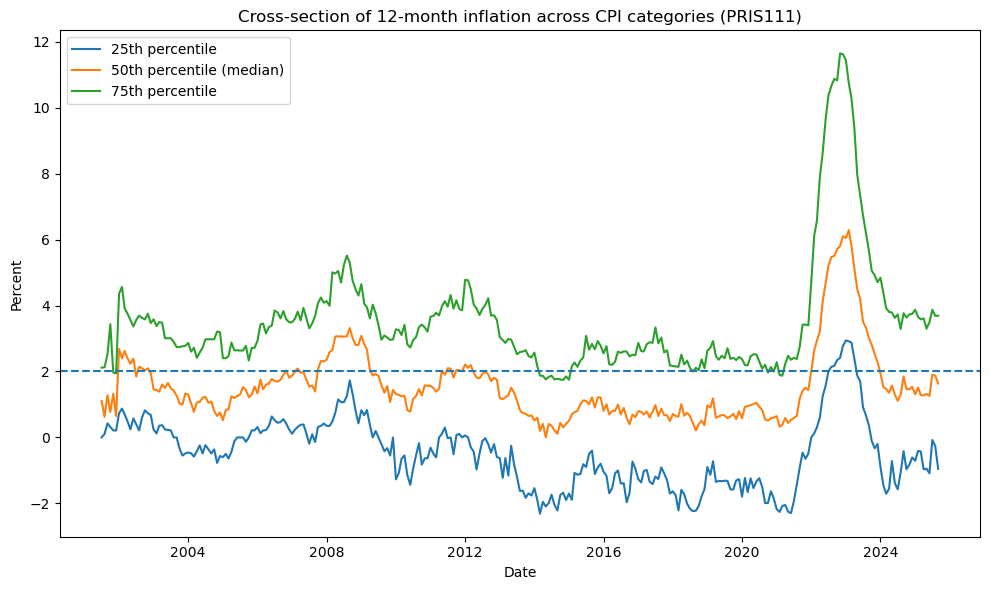

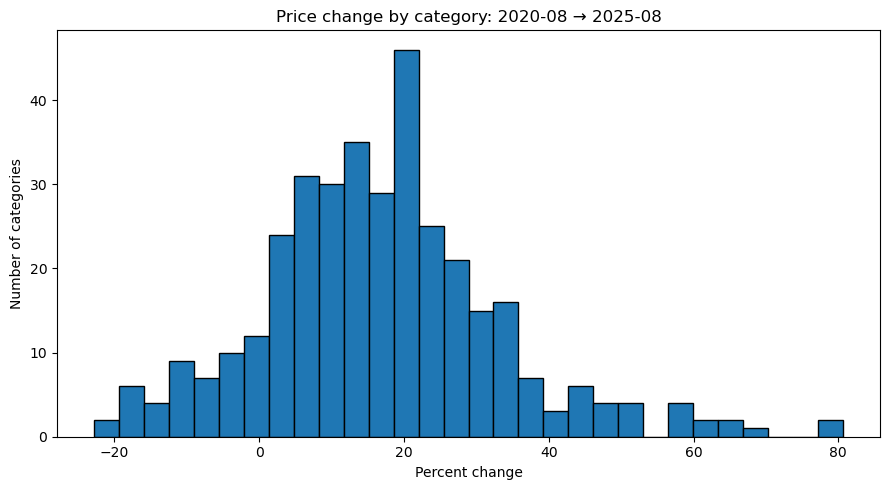

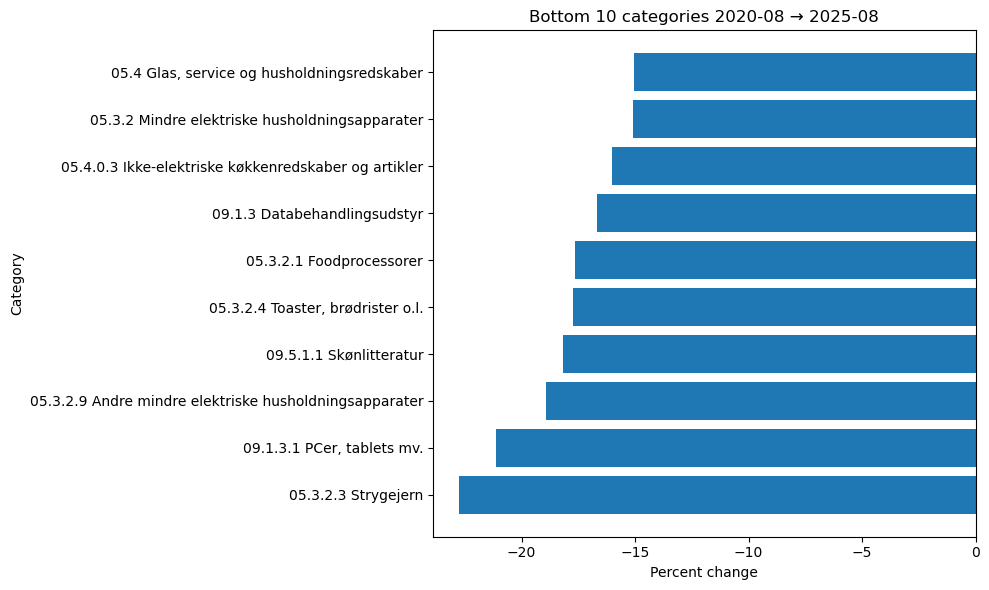

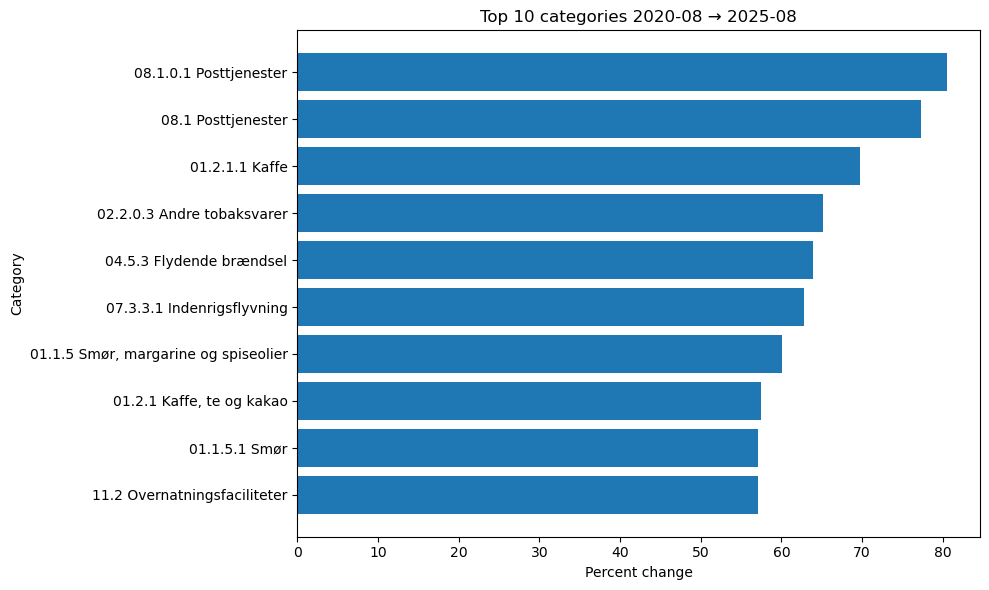

In [52]:
# Helper functions (reusing logic from 1.3)

def pick_enhed_id(v: dict) -> str:
    """
    Choose an ENHED (unit) that represents an index level, not a pct change.
    Prefer something that looks like an index with base '=100' or '2015=100'.
    Fallback: the first available value.
    """
    bad_words = ("pct", "procent", "ændring", "aendring", "change", "%")
    candidates = []
    for val in v.get("values", []):
        txt = (val.get("text", "") or "")
        txt_l = txt.lower()
        if (
            ("index" in txt_l or "=100" in txt_l or "2015" in txt_l or "100" in txt_l)
            and not any(b in txt_l for b in bad_words)
        ):
            # score: prefer explicit base info
            score = 2 * ("2015" in txt_l) + ("=100" in txt_l or "100" in txt_l)
            candidates.append((score, val["id"], txt))
    if candidates:
        candidates.sort(reverse=True)  # best score first
        best = candidates[0]
        return best[1]

    # fallback: just take the first value
    return v["values"][0]["id"]

def pick_season_id(v: dict) -> str:
    """
    Prefer 'not seasonally adjusted' if available.
    Fallback: first available value.
    """
    for val in v.get("values", []):
        txt = (val.get("text", "") or "").lower()
        if "ikke sæson" in txt or "not season" in txt or "not seasonally" in txt:
            return val["id"]
    return v["values"][0]["id"]


# --------------------------------------------------------
# STEP 0. Fetch full CPI panel from PRIS111 at product-group level
# PRIS113 is headline aggregates. PRIS111 is detailed by product group (VAREGR),
# which is what we need here.
# --------------------------------------------------------

api = DstApi("PRIS111")
meta = api.tableinfo(language="da")  # 'da' because column labels etc. come from DST in Danish

# Identify the time variable in metadata
time_var = meta.get("time")
if time_var is None:
    # fallback: search manually
    for v in meta.get("variables", []):
        vid = (v.get("id", "") or "").lower()
        vtxt = (v.get("text", "") or "").lower()
        if any(k in vtxt for k in ("tid", "time", "måned", "maaned", "month", "periode")):
            time_var = v
            break
time_code = time_var["id"] if time_var is not None else "TID"

# Identify product group variable (VAREGR)
varegr_var = next(
    (v for v in meta["variables"] if v.get("id", "").upper() == "VAREGR"),
    None
)
if varegr_var is None:
    raise RuntimeError("Could not find VAREGR in PRIS111 metadata.")
varegr_code = varegr_var["id"]

# Identify ENHED (unit / index definition, like '2015=100')
enhed_var = next(
    (
        v for v in meta["variables"]
        if "ENHED" in v.get("id", "").upper()
        or "enhed" in v.get("text", "").lower()
        or "unit"  in v.get("text", "").lower()
    ),
    None
)

# Identify a seasonal-adjustment dimension if present
season_var = next(
    (
        v for v in meta["variables"]
        if "sæson" in v.get("text", "").lower()
        or "saeson" in v.get("text", "").lower()
        or "season" in v.get("text", "").lower()
    ),
    None
)

# Build the variables payload for the API call.
# We want:
# - VAREGR: all product groups ("*")
# - ENHED: pick one index level definition (not % change)
# - Season: pick "not seasonally adjusted" if available
# - Time: all months
variables_payload = []
for v in meta["variables"]:
    code = v["id"]
    if code == time_code:
        continue
    if code == varegr_code:
        variables_payload.append({"code": code, "values": ["*"]})
    elif enhed_var is not None and code == enhed_var["id"]:
        variables_payload.append({"code": code, "values": [pick_enhed_id(enhed_var)]})
    elif season_var is not None and code == season_var["id"]:
        variables_payload.append({"code": code, "values": [pick_season_id(season_var)]})
    else:
        # Any other dimension: just take the first available value
        first_val = v["values"][0]["id"] if v.get("values") else "*"
        variables_payload.append({"code": code, "values": [first_val]})

# Add the time dimension (all periods)
variables_payload.append({"code": time_code, "values": ["*"]})

params = {
    "table": "PRIS111",
    "format": "CSV",
    "lang": "da",   # keep Danish labels; numeric content isn't affected
    "variables": variables_payload,
}

raw = api.get_csv(params)


# --------------------------------------------------------
# STEP 1. Clean data (date, category text, numeric index level)
# --------------------------------------------------------

# Find likely column names for time and value
time_col = next(
    c for c in raw.columns
    if c.lower() in ("tid", "time", "måned", "maaned", "month", "periode")
)

value_col = next(
    c for c in raw.columns
    if c.lower() in ("indhold", "value", "values", "data")
)

# PRIS111 should also give a column "VAREGR"
df = raw[[time_col, "VAREGR", value_col]].copy()
df.rename(
    columns={
        time_col: "date_raw",
        "VAREGR": "category",
        value_col: "level_raw",
    },
    inplace=True,
)

# Parse the DST time labels into pandas Timestamps using your existing helper
df["date"] = parse_time_column(df["date_raw"])

# Parse numeric levels robustly (Danish decimal commas / thousands separators)
if pd.api.types.is_numeric_dtype(df["level_raw"]):
    df["level"] = df["level_raw"].astype(float)
else:
    df["level"] = (
        df["level_raw"]
        .astype(str)
        .str.replace(".", "", regex=False)   # remove thousands separator dot
        .str.replace(",", ".", regex=False)  # decimal comma -> dot
        .pipe(pd.to_numeric, errors="coerce")
    )

# Extract a clean product code prefix from the category text.
# Examples:
#   "01.1.1.1 Bread"            -> cat_code "01.1.1.1"
#   "04.5.1 Electricity"        -> cat_code "04.5.1"
# We allow multiple dot groups, e.g. \d{2} then .\d etc.
df["cat_code"] = df["category"].str.extract(r"^(\d{2}(?:\.\d+)+)")

# Keep only rows that correspond to an actual product code
df_det = df[df["cat_code"].notna()].copy()


# --------------------------------------------------------
# 1.4.1 List all detailed product categories
# --------------------------------------------------------

cat_list = (
    df_det[["cat_code", "category"]]
    .drop_duplicates()
    .sort_values("cat_code")
    .reset_index(drop=True)
)

print("Detailed CPI product categories (code + label):")
for row in cat_list.itertuples(index=False):
    print(f"{row.cat_code}  {row.category}")


# --------------------------------------------------------
# 1.4.2 Cross-sectional dispersion of 12-month inflation
#      We compute YoY inflation for each product group, then
#      take the 25th/50th/75th percentiles across groups each month.
# --------------------------------------------------------

# Sort by (cat_code, date) so pct_change(12) works as intended
df_det = df_det.sort_values(["cat_code", "date"])
df_det["yoy_pct"] = (
    df_det.groupby("cat_code")["level"]
    .pct_change(12) * 100.0
)

# For each month, compute percentiles of YoY across categories
quantiles = (
    df_det
    .dropna(subset=["yoy_pct"])
    .groupby("date")["yoy_pct"]
    .agg(
        p25=lambda s: s.quantile(0.25),
        p50="median",
        p75=lambda s: s.quantile(0.75),
    )
    .reset_index()
    .sort_values("date")
)

plt.figure(figsize=(10,6))
plt.plot(quantiles["date"], quantiles["p25"], label="25th percentile")
plt.plot(quantiles["date"], quantiles["p50"], label="50th percentile (median)")
plt.plot(quantiles["date"], quantiles["p75"], label="75th percentile")
plt.axhline(2, linestyle="--")
plt.title("Cross-section of 12-month inflation across CPI categories (PRIS111)")
plt.xlabel("Date")
plt.ylabel("Percent")
plt.legend()
plt.tight_layout()
plt.show()

# Write-up guidance:
# - The median shows the 'typical' category's inflation.
# - The gap between 75th and 25th shows how broad or narrow the price pressure is.
# - If all three lines come down toward ~2%, that means inflation is cooling broadly.


# --------------------------------------------------------
# 1.4.3 Histogram of cumulative price changes
#      from Aug 2020 to Aug 2025 (or latest available month)
# --------------------------------------------------------

start_month = pd.Timestamp("2020-08-01")
target_month_guess = pd.Timestamp("2025-08-01")

# Pivot to wide: rows = category code, columns = dates, values = price index level
wide_levels = (
    df_det.pivot_table(
        index="cat_code",
        columns="date",
        values="level",
        aggfunc="first",
    )
)

if start_month not in wide_levels.columns:
    raise RuntimeError("Start month 2020-08 was not found in the dataset. Pick another start month.")

if target_month_guess in wide_levels.columns:
    end_month = target_month_guess
else:
    end_month = wide_levels.columns.max()

# Total cumulative % change over the window
pct_change_total = (
    (wide_levels[end_month] / wide_levels[start_month] - 1.0) * 100.0
).dropna()

plt.figure(figsize=(9,5))
plt.hist(pct_change_total, bins=30, edgecolor="black")
plt.title(f"Price change by category: {start_month:%Y-%m} → {end_month:%Y-%m}")
plt.xlabel("Percent change")
plt.ylabel("Number of categories")
plt.tight_layout()
plt.show()

# Write-up guidance:
# - A fat right tail means a few categories exploded in price.
# - If most mass sits around, say, +10–20%, that means broad moderate increases.
# - This tells you if inflation was driven by a few outliers or was broad-based.


# --------------------------------------------------------
# 1.4.4 Top 10 and bottom 10 categories
#      Rank categories by total price change since Aug 2020.
# --------------------------------------------------------

# Build a lookup from cat_code -> human-readable category text
name_lookup = (
    df_det[["cat_code", "category"]]
    .drop_duplicates(subset=["cat_code"])
    .set_index("cat_code")["category"]
)

rank_df = (
    pct_change_total
    .to_frame(name="pct_change_total")
    .join(name_lookup, how="left")
    .sort_values("pct_change_total")
)

bottom10 = rank_df.head(10).copy()   # smallest price increase (or declines)
top10    = rank_df.tail(10).copy()   # largest price increases

# Bottom 10 barh
plt.figure(figsize=(10,6))
plt.barh(bottom10["category"], bottom10["pct_change_total"])
plt.title(f"Bottom 10 categories {start_month:%Y-%m} → {end_month:%Y-%m}")
plt.xlabel("Percent change")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

# Top 10 barh (sorted ascending so bars go upward nicely)
top10_sorted = top10.sort_values("pct_change_total")
plt.figure(figsize=(10,6))
plt.barh(top10_sorted["category"], top10_sorted["pct_change_total"])
plt.title(f"Top 10 categories {start_month:%Y-%m} → {end_month:%Y-%m}")
plt.xlabel("Percent change")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

# Write-up guidance:
# - The Top 10 are the categories that drove the inflation story after 2020.
# - The Bottom 10 are those with very mild increases or even falling prices.
# - Connect this to your 1.3 result: if "energy" and "food" dominate the Top 10,
#   that supports the narrative that the inflation spike was energy/food driven.


## Question 2

### 2.1 CPI vs HICP

In [53]:
from fredapi import Fred

# 1. Load FRED API key from file and create a Fred object
with open("fredapi_key.txt", "r") as f:
    fred = Fred(api_key=f.read().strip())
    

In [54]:
# 2. Series codes for HICP (All Items), by country/area
SERIES_CODES = {
    "Denmark": "CP0000DKM086NEST",
    "Austria": "CP0000ATM086NEST",
    "Euro Area": "CP0000EZCCM086NEST",   # Euro Area HICP (All Items)
    "United States": "CP0000USM086NEST", # Harmonized CPI for the US
}

# Helper function: download a series safely and return as pandas Series
def fetch_series(series_id: str) -> pd.Series:
    sid = series_id.strip().upper()  # remove hidden whitespace/newlines
    s = fred.get_series(sid)
    s.name = sid
    return s

# 3. Download all series into one DataFrame
data_columns = {}
for region, sid in SERIES_CODES.items():
    s = fetch_series(sid)
    s.name = region  # rename column to readable label
    data_columns[region] = s

hicp = pd.concat(data_columns.values(), axis=1)

In [55]:
# Ensure datetime index
hicp.index = pd.to_datetime(hicp.index)

# Keep only observations from 2019 onward
hicp = hicp.loc[hicp.index >= "2019-01-01"]

# 4. Compute 12-month (year-over-year) inflation rates
# Formula: inflation_t = (HICP_t / HICP_{t-12} - 1) * 100
inflation_yoy = hicp.pct_change(periods=12) * 100


/var/folders/j0/qzh343x57q9djs607v5lcwkr0000gn/T/ipykernel_79488/3166902968.py:9: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  inflation_yoy = hicp.pct_change(periods=12) * 100


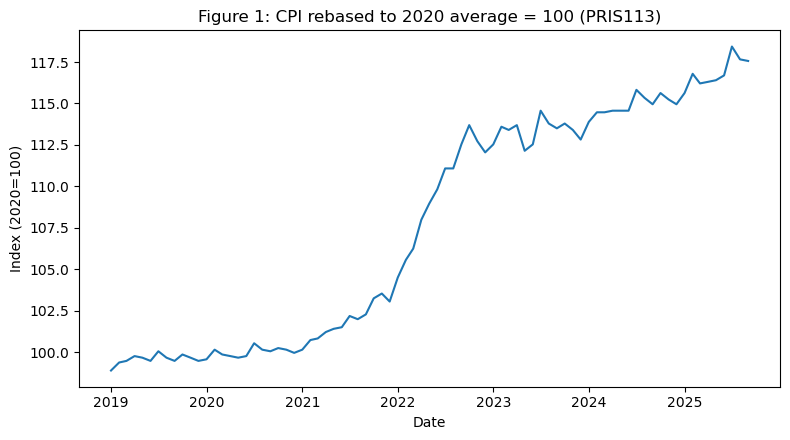

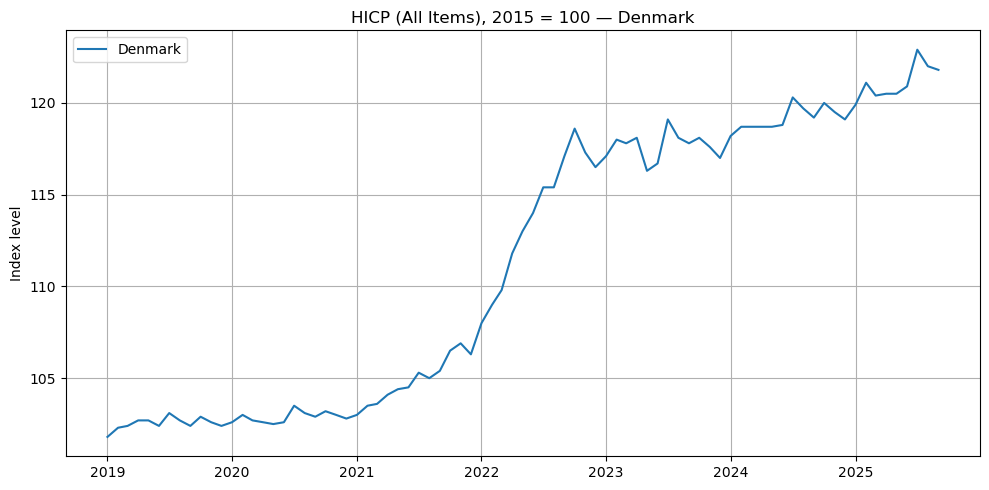

In [56]:
# Defining a new class for the DST API
class DstApi:
    def __init__(self, table_id: str):
        self.table_id = table_id.upper()

    def tableinfo(self, language: str = "da") -> dict:
        """Fetch metadata for the table."""
        payload = {"table": self.table_id, "format": "JSON", "lang": language}
        r = requests.post(f"{BASE}/tableinfo", json=payload)
        r.raise_for_status()
        return r.json()

    def get_csv(self, params: dict) -> pd.DataFrame:
        """
        Fetch data as CSV and return a pandas DataFrame.
        """
        r = requests.post(f"{BASE}/data", json=params)
        r.raise_for_status()
        return pd.read_csv(StringIO(r.text), sep=";", decimal=",") 

def pick_cpi_value_id(meta: dict) -> tuple[str, str]:
    """
    We find the variable and value-id that correspond to the 'Forbrugerprisindeks' aggregate in PRIS113.
    Returns (variable_code, value_id). Raises if not found.
    """
    for v in meta.get("variables", []):
        texts = [val.get("text", "").lower() for val in v.get("values", [])]
        ids   = [val.get("id") for val in v.get("values", [])]
        for val_text, val_id in zip(texts, ids):
            if "forbrugerprisindeks" in val_text:
                return v["id"], val_id
    raise RuntimeError("Could not find 'Forbrugerprisindeks' in PRIS113 metadata. Inspect tableinfo() output.")

def parse_time_column(series: pd.Series) -> pd.Series:
    """
    Convert DST monthly labels like '2020M01' into pandas Timestamps.
    """
    def _parse(s: str):
        s = str(s).strip().replace("M", "-")  # '2020M01' -> '2020-01'
        try:
            return pd.to_datetime(s, format="%Y-%m")
        except Exception:
            return pd.to_datetime(s, errors="coerce")
    return series.apply(_parse)

# ---------- 1) Setup and metadata ----------
api = DstApi("PRIS113")
meta = api.tableinfo(language="da")

# Choose CPI aggregate
var_code, cpi_id = pick_cpi_value_id(meta)

# Build request params: CPI aggregate + all months
params = {
    "table": "PRIS113",
    "format": "CSV",
    "lang": "da",
    "variables": [
        {"code": var_code, "values": [cpi_id]},
        # Time may be named 'TID' in StatBank tables
        {"code": meta["time"]["id"] if "time" in meta else "TID", "values": ["*"]},
    ],
}

# ---------- 2) Fetch data ----------
raw = api.get_csv(params)

# ---------- 3) Tidy / validation ----------
# Identify time and value columns robustly
time_candidates  = [c for c in raw.columns if c.lower() in ("tid", "time", "måned", "maaned", "month")]
value_candidates = [c for c in raw.columns if c.lower() in ("indhold", "value", "values", "data")]
if not time_candidates or not value_candidates:
    raise RuntimeError(f"Could not infer time/value columns from: {list(raw.columns)}")

tcol = time_candidates[0]
vcol = value_candidates[0]

df = raw.copy()
df["date"] = parse_time_column(df[tcol])
df["cpi_2015eq100"] = pd.to_numeric(df[vcol], errors="coerce")

# Sanity checks
if df["date"].isna().all():
    raise RuntimeError("All parsed dates are NaT. Check the time column format in the fetched CSV.")
if df["cpi_2015eq100"].isna().all():
    # This usually means decimal commas were not parsed; but we set decimal="," above.
    raise RuntimeError("All CPI values are NaN. Check parsing (separator/decimal) and the selected series.")

df = df.sort_values("date").reset_index(drop=True)

# ---------- 4) Rebase to 2020 average = 100 ----------
base_2020 = df.loc[df["date"].dt.year == 2020, "cpi_2015eq100"].mean()
if pd.isna(base_2020):
    raise RuntimeError("No 2020 observations found to compute the 2020-average base.")
df["cpi_2020avg_100"] = df["cpi_2015eq100"] / base_2020 * 100.0

# ---------- 5) Inflation rates ----------
df["mom_inflation_pct"] = df["cpi_2015eq100"].pct_change(1) * 100.0      # month-over-month
df["yoy_inflation_pct"] = df["cpi_2015eq100"].pct_change(12) * 100.0     # year-over-year

# constrain to 2019 and onwards
df_2019 = df[df["date"].dt.year >= 2019]

# Plotting the figures. First figure 1: CPI rebased to 2020 average = 100
plt.figure(figsize=(8, 4.5))
plt.plot(df_2019["date"], df_2019["cpi_2020avg_100"])
plt.title("Figure 1: CPI rebased to 2020 average = 100 (PRIS113)")
plt.xlabel("Date")
plt.ylabel("Index (2020=100)")
plt.tight_layout()
plt.show()

# Plotting HICP levels for Denmark
plt.figure(figsize=(10,5))
plt.plot(hicp.index, hicp["Denmark"], label="Denmark")
plt.title("HICP (All Items), 2015 = 100 — Denmark")
plt.ylabel("Index level")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### 2.2 Across countries

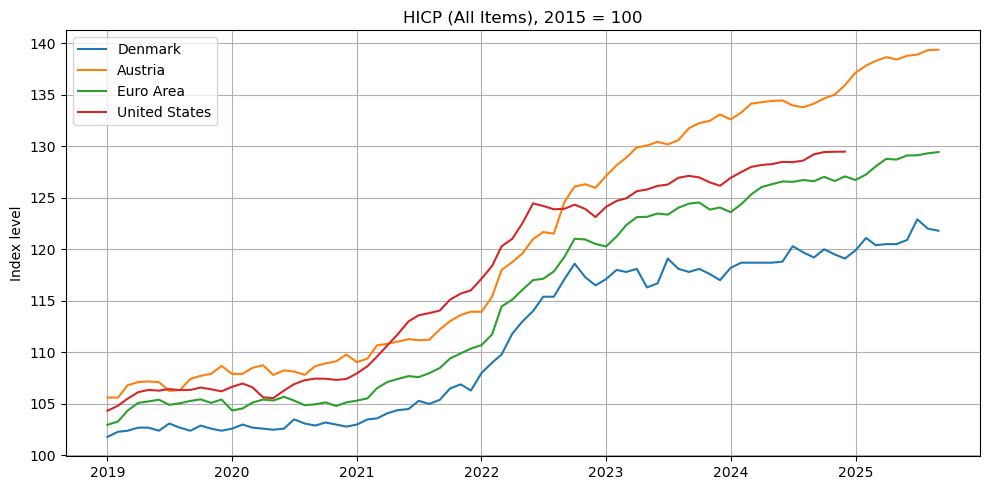

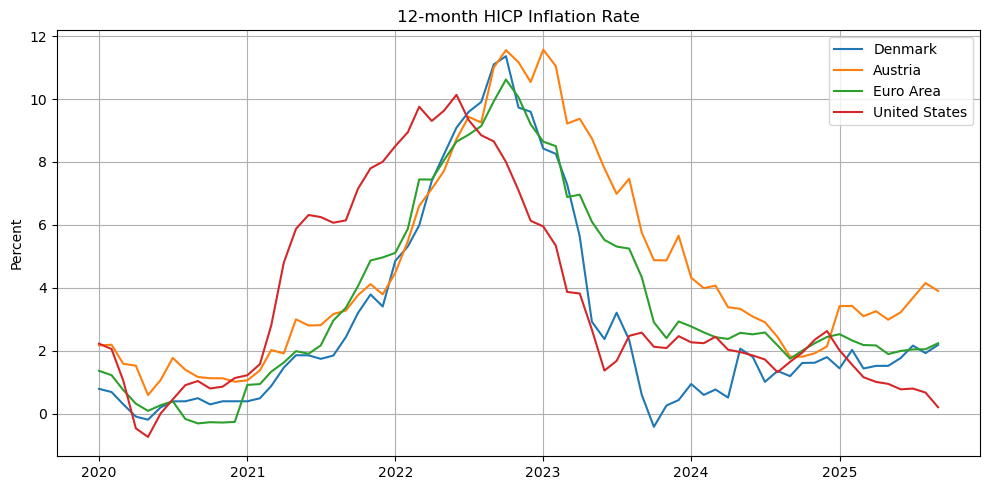


=== Yearly statistics for 12-month HICP inflation (percent) ===
(Rows = year, Columns = country, Sub-columns = min / max / mean)

           Denmark              Austria              Euro Area               \
               min    max  mean     min    max  mean       min    max  mean   
2019-12-31     NaN    NaN   NaN     NaN    NaN   NaN       NaN    NaN   NaN   
2020-12-31   -0.19   0.79  0.33    0.59   2.19  1.39     -0.31   1.36  0.26   
2021-12-31    0.39   3.79  1.94    1.06   4.11  2.76      0.91   4.96  2.59   
2022-12-31    4.85  11.36  8.51    4.48  11.55  8.59      5.11  10.62  8.36   
2023-12-31   -0.42   8.43  3.44    4.87  11.57  7.78      2.40   8.64  5.48   
2024-12-31    0.51   2.06  1.27    1.81   4.32  2.93      1.74   2.77  2.37   
2025-12-31    1.43   2.18  1.77    2.98   4.15  3.46      1.89   2.52  2.15   

           United States               
                     min    max  mean  
2019-12-31           NaN    NaN   NaN  
2020-12-31         -0.74   2.22  0.77

/var/folders/j0/qzh343x57q9djs607v5lcwkr0000gn/T/ipykernel_79488/705804558.py:27: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  .resample("Y")          # calendar year (year-end frequency)


In [57]:
# 5. Plot HICP index levels
plt.figure(figsize=(10,5))
for country in hicp.columns:
    plt.plot(hicp.index, hicp[country], label=country)
plt.title("HICP (All Items), 2015 = 100")
plt.ylabel("Index level")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# 6. Plot 12-month HICP inflation rates
plt.figure(figsize=(10,5))
for country in inflation_yoy.columns:
    plt.plot(inflation_yoy.index, inflation_yoy[country], label=country)
plt.title("12-month HICP Inflation Rate")
plt.ylabel("Percent")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# 7. Yearly summary statistics:
#    For each year and each country, compute the min, max, and mean
annual_stats = (
    inflation_yoy
    .resample("Y")          # calendar year (year-end frequency)
    .agg(["min", "max", "mean"])
    .round(2)
)

print("\n=== Yearly statistics for 12-month HICP inflation (percent) ===")
print("(Rows = year, Columns = country, Sub-columns = min / max / mean)\n")
print(annual_stats)

# 8. Average inflation since 2019 by country
avg_since_2019 = inflation_yoy.mean().round(2)
print("\n=== Average 12-month HICP inflation since 2019 (percent) ===")
print(avg_since_2019)




## 3 Extension

### 3.1 Consumer prices effect on real hourly wages in denmark

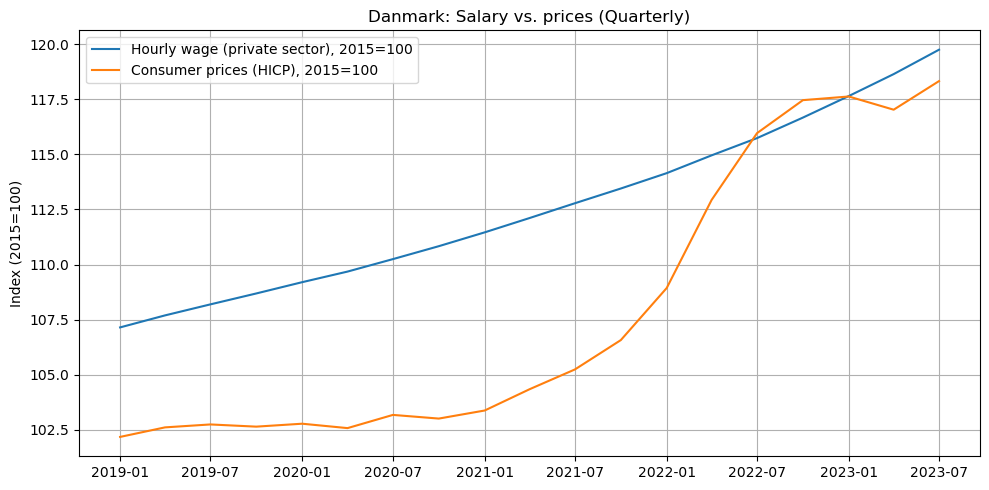

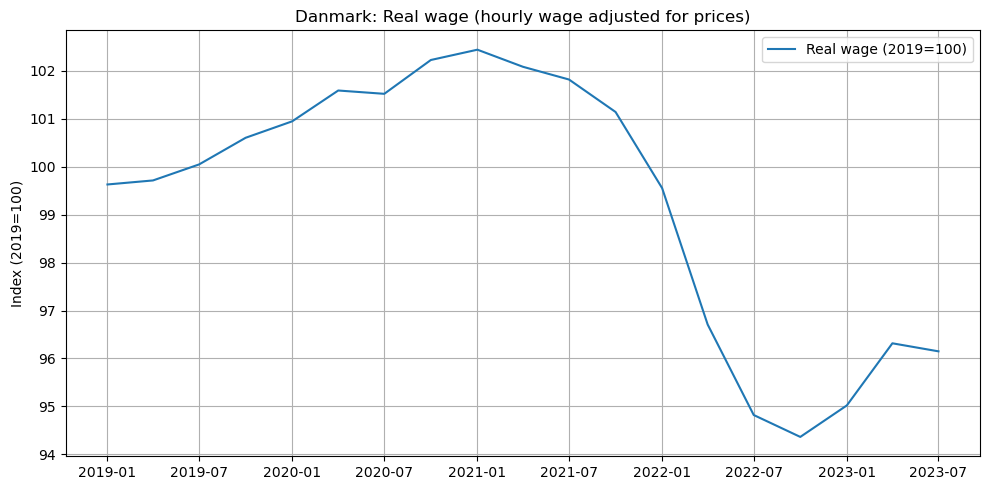

In [58]:


# FRED-kode for hourly wage in private sector, Denmark
WAGE_SERIES_ID = "LCEAPR01DKQ661S"  # Labor Compensation: Earnings: Private Sector: Hourly for Denmark

# function to fetch a series from FRED as a pandas Series
def fetch_fred_series(series_id: str) -> pd.Series:
    s = fred.get_series(series_id.strip().upper())
    s.name = series_id
    return s

dk_wage_q = fetch_fred_series(WAGE_SERIES_ID)

# change to dataframe with proper name
dk_wage_q = dk_wage_q.to_frame(name="DK_wage_index_2015eq100")

# index as datetime (FRED gives PeriodIndex 'Q', sometimes it becomes Timestamp directly.
# try to convert robustly)
dk_wage_q.index = pd.to_datetime(dk_wage_q.index)

# clip to more recent period (from 2019 onwards)
dk_wage_q = dk_wage_q.loc[dk_wage_q.index >= "2019-01-01"]

# B. Make quarterly HICP for Denmark ---------------------

dk_hicp_m = hicp["Denmark"].to_frame(name="DK_hicp_index_2015eq100").copy()
dk_hicp_m.index = pd.to_datetime(dk_hicp_m.index)
dk_hicp_m = dk_hicp_m.loc[dk_hicp_m.index >= "2019-01-01"]

# Use 'QS' (Quarter Start) instead of 'Q' (Quarter End)
dk_hicp_q = dk_hicp_m.resample("QS").mean()

# C. Merging salary and prices-----------------------

dk_wage_q.index = pd.to_datetime(dk_wage_q.index)
dk_wage_q = dk_wage_q.loc[dk_wage_q.index >= "2019-01-01"]

df_q = pd.concat([dk_wage_q, dk_hicp_q], axis=1, join="inner").dropna()

# D. Realwage ---------------------------------------------

df_q["DK_real_wage_index_2015eq100"] = (
    df_q["DK_wage_index_2015eq100"] / df_q["DK_hicp_index_2015eq100"] * 100
)

base_2019 = df_q.loc[df_q.index.year == 2019, "DK_real_wage_index_2015eq100"].mean()
df_q["DK_real_wage_index_2019avg100"] = (
    df_q["DK_real_wage_index_2015eq100"] / base_2019 * 100
)

# E. Figur 1: Salary vs prices -------------------------------

plt.figure(figsize=(10,5))
plt.plot(df_q.index, df_q["DK_wage_index_2015eq100"], label="Hourly wage (private sector), 2015=100")
plt.plot(df_q.index, df_q["DK_hicp_index_2015eq100"], label="Consumer prices (HICP), 2015=100")
plt.title("Danmark: Salary vs. prices (Quarterly)")
plt.ylabel("Index (2015=100)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# F. Figur 2: Real wage -------------------------------------

plt.figure(figsize=(10,5))
plt.plot(df_q.index, df_q["DK_real_wage_index_2019avg100"], label="Real wage (2019=100)")
plt.title("Danmark: Real wage (hourly wage adjusted for prices)")
plt.ylabel("Index (2019=100)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



In this section we seek to understand how the consumer prices affects the hourly wages of danish workers occupied in the private sector. 
We find that the consumer prices rise in the beggining of 2021, and as a result of that the real hourly wage falls, meaning that the received salary has less buying power than before the change in consumer prices.